# Домашнє завдання: Інтерактивні візуалізації з Plotly

## Опис завдання
У цьому домашньому завданні ви будете створювати інтерактивні візуалізації з допомогою бібліотеки Plotly. Ви дізнаєтесь різницю між Plotly Express (швидкі графіки) та Graph Objects (повний контроль), та створите інтерактивний дашборд.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---

🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Для plotly краще не встановлювати datetime як індекс
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.day_name()

# Додаємо назви кварталів в окрему колонку
quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
df['quarter_name'] = df['season'].map(quarter_map)

In [2]:
# Сезони Індії за місяцями
# 1 = Winter, 2 = Summer, 3 = Monsoon, 4 = Post-Monsoon

season_num_map_india = {
    12: 1, 1: 1, 2: 1,          # Winter
    3: 2, 4: 2, 5: 2,           # Summer
    6: 3, 7: 3, 8: 3, 9: 3,     # Monsoon
    10: 4, 11: 4                # Post-Monsoon
}

df['season_india'] = df['month'].map(season_num_map_india)

# Текстові назви сезонів
season_name_map_india = {
    1: 'Winter',
    2: 'Summer',
    3: 'Monsoon',
    4: 'Post-Monsoon'
}

df['season_india_name'] = df['season_india'].map(season_name_map_india)

## Завдання 1: Базовий інтерактивний лінійний графік (Plotly Express)

**Завдання:**
Створіть інтерактивний лінійний графік динаміки оренди за часом (рівень деталізації - як в даних) з можливістю zoom та hover.

Дайте відповіді на питання.
**Питання для інтерпретації:**
1. Яка перевага інтерактивного графіка над статичним?
2. Чому на графіку є "пробіли" - ділянки, де одна пряма лінія зʼєднує два "суцільних" блоки з даними? Як би ви це могли дослідити на статичному графіку?


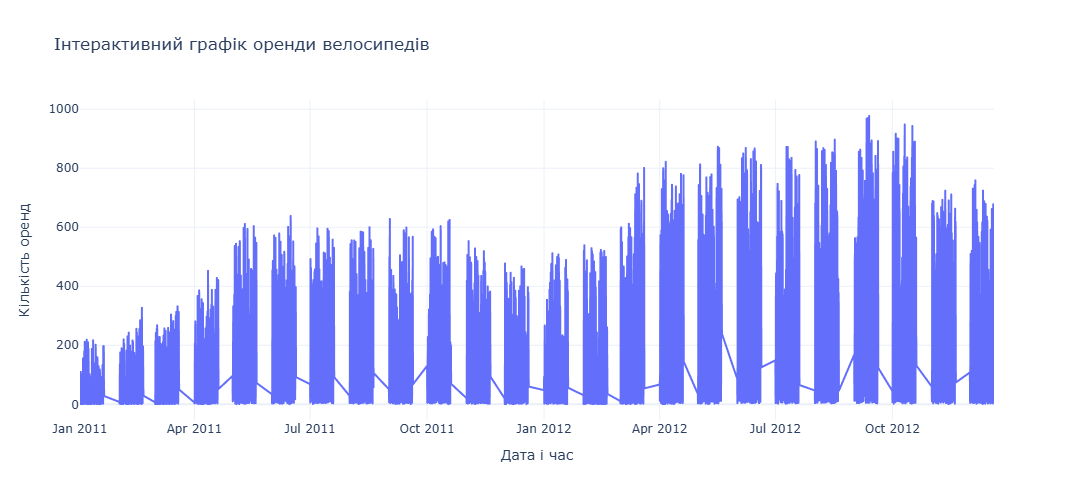

In [3]:
fig = px.line(df, x='datetime', y='count',
              title='Інтерактивний графік оренди велосипедів')
fig.update_traces(line_width=2)
fig.update_layout(
    template='plotly_white',
    height=500,
    xaxis_title='Дата і час',
    yaxis_title='Кількість оренд'
)

Інтерактивний графік дає змогу детальніше досліджувати дані: наводити курсор на точки і бачити точні значення, наближати окремі ділянки та зручно переглядати часові проміжки. Це особливо корисно для часових рядів із великою кількістю спостережень.


"Пробіли" виникають через відсутність записів для деяких дат або годин у часовому ряді. Plotly з’єднує наявні точки лінією, тому між окремими блоками даних можуть бути помітні розриви або довгі переходи. На статичному графіку це теж можна побачити, але інтерактивний формат дозволяє легше наблизити проблемну ділянку й перевірити конкретні часові точки.

## Завдання 2: Scatter plot з додатковими даними (Plotly Express)

**Завдання:**
Створіть scatter plot кількості орендованих велосипедів випадковими користувачами vs кількості орендованих велосипедів зареєстрованими користувачами. Розмір точок встановіть за сумарною кількістю велосипедів, які були взяті в оренду, а колір - за сезоном(кварталом). В hover_data - додайте деталі, які допоможуть вам в подальшому аналізі.

Дослідіть графік. Зверніть увагу, що ви можете вмикати і вимикати окремі квартали, якщо будете клікати на колір кварталу в легенді графіку.

**Дайте відповідь на питання.**
- Як ви проінтерпретуєте роздвоєність цього графіку (дві явні лінії)? Що це означає?
- Які висновки для компанії, які дає велосипеди в оренду, ви можете зробити з цього графіку? 3 основних висновки.

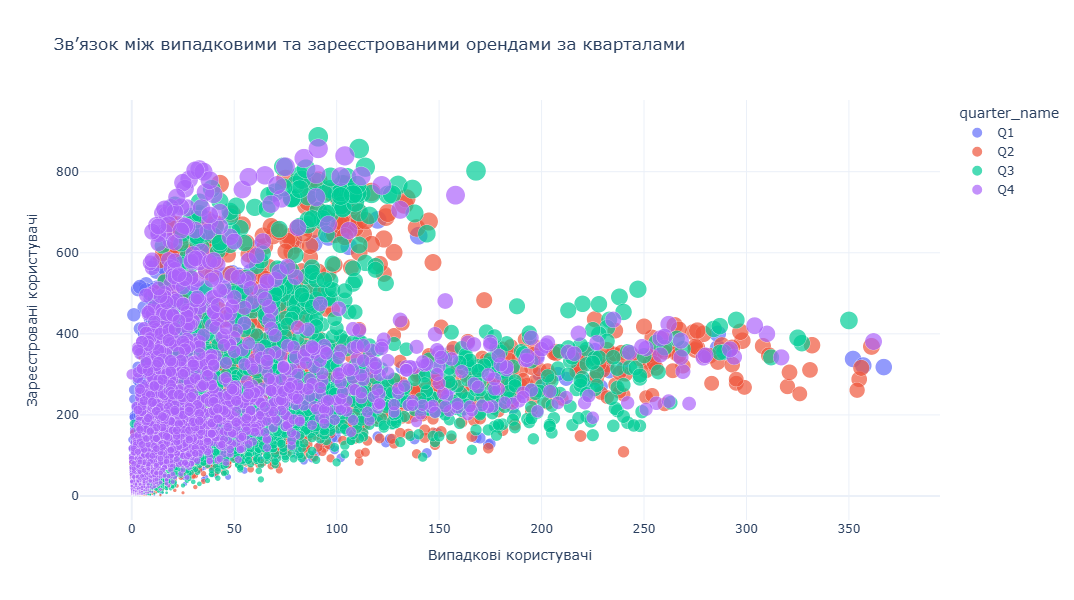

In [4]:
fig = px.scatter(df,
                 x='casual',
                 y='registered',
                 size='count',
                 color='quarter_name',
                 title='Зв’язок між випадковими та зареєстрованими орендами за кварталами',
                 custom_data=['quarter_name', 'season_india_name', 'count'],
                 template='plotly_white'
                )

fig.update_layout(
    height=600,
    xaxis_title='Випадкові користувачі',
    yaxis_title='Зареєстровані користувачі'
)

fig.update_traces(
    marker=dict(line=dict(width=0.5, color='white')),
    hovertemplate=
    '<b>Квартал:</b> %{customdata[0]}<br>' +
    '<b>Сезон:</b> %{customdata[1]}<br>' +
    '<b>Випадкові:</b> %{x}<br>' +
    '<b>Зареєстровані:</b> %{y}<br>' +
    '<b>Усього оренд:</b> %{customdata[2]}<extra></extra>'
)

fig.show()

Роздвоєність графіка свідчить, що в даних є щонайменше два різні патерни попиту. Імовірно, це пов’язано із сезонністю, різницею між більш і менш активними періодами, а також відмінностями у поведінці користувачів у різні дні та часові проміжки. Тобто попит формується не лише одним фактором.

**Висновки для компанії**

1. **Зареєстровані користувачі формують основну частину попиту.**  
   На графіку видно, що в багатьох спостереженнях кількість зареєстрованих користувачів вища за кількість випадкових. Це означає, що саме постійні клієнти є основою більш стабільного попиту.

2. **Активні квартали потребують більшої готовності сервісу.**  
   Найбільші точки частіше трапляються у Q2–Q3, тому в ці періоди компанії важливо заздалегідь планувати достатню кількість велосипедів, персоналу та ресурсів для обслуговування.

3. **Випадкових користувачів варто конвертувати в постійних.**  
   На графіку є багато точок із помітною кількістю casual-користувачів, тому для бізнесу це сигнал працювати з акціями, програмами лояльності та зручними умовами реєстрації, щоб переводити частину таких клієнтів у категорію зареєстрованих.

## Завдання 3: Порівняння Plotly Express vs Graph Objects

**Завдання:**
Створіть лінійний графік помісячної динаміки оренди (кількість оренд) велосипедів двома способами - з Plotly Express та з Graph Objects.

**Дайте відповіді на питання.**
1. Як ви розумієте основну різницю між цими двома підходами?
2. Коли краще використовувати Plotly Express?
3. Коли потрібен Graph Objects?


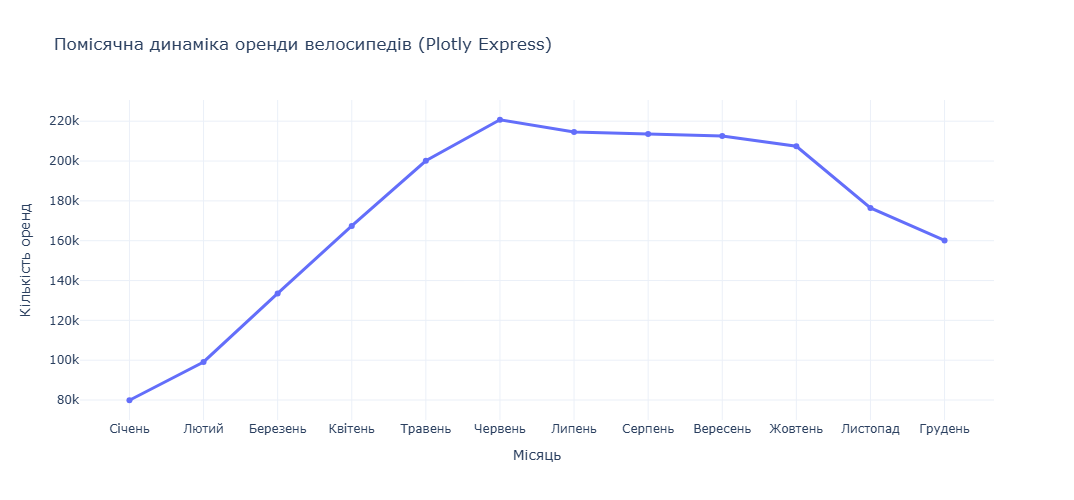

In [5]:
monthly_rentals = (
    df.groupby('month', as_index=False)['count'].sum().sort_values('month')
)
month_labels_ua = {
    1: 'Січень', 2: 'Лютий', 3: 'Березень', 4: 'Квітень',
    5: 'Травень', 6: 'Червень', 7: 'Липень', 8: 'Серпень',
    9: 'Вересень', 10: 'Жовтень', 11: 'Листопад', 12: 'Грудень'
}

monthly_rentals['month_name_ua'] = monthly_rentals['month'].map(month_labels_ua)

# Графік 1: Plotly Express
fig = px.line(monthly_rentals, x='month', y='count', markers=True,
              title='Помісячна динаміка оренди велосипедів (Plotly Express)',
              custom_data=['month_name_ua']
)

fig.update_traces(line_width=3, hovertemplate='<b>Місяць:</b> %{customdata[0]}<br><b>Кількість оренд:</b> %{y:,}<extra></extra>')
fig.update_layout(
    template='plotly_white',
    height=500,
    xaxis=dict(
        tickmode='array',
        tickvals=monthly_rentals['month'],
        ticktext=monthly_rentals['month_name_ua']
    ),
    xaxis_title='Місяць',
    yaxis_title='Кількість оренд'
)

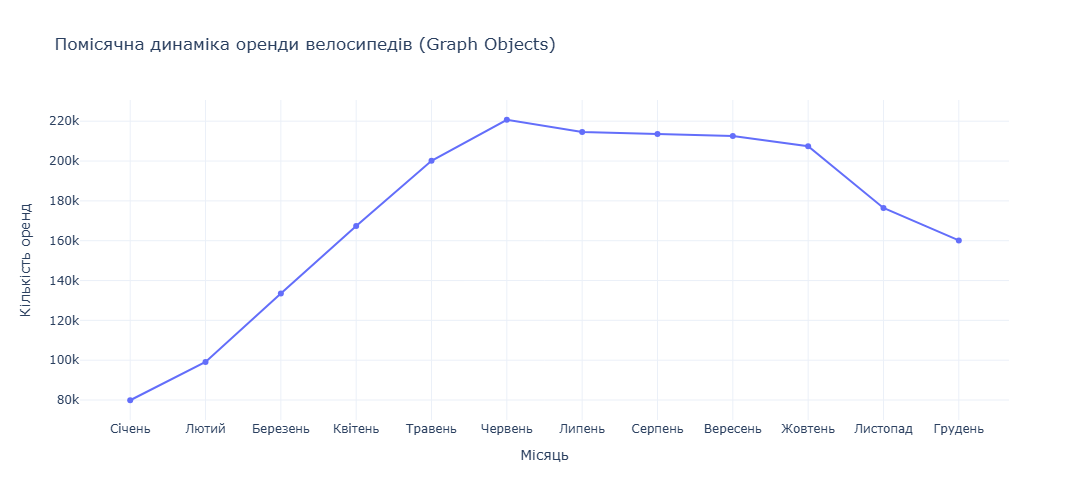

In [6]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=monthly_rentals['month'],
        y=monthly_rentals['count'],
        mode='lines+markers',
        customdata=monthly_rentals['month_name_ua'],
        hovertemplate='<b>Місяць:</b> %{customdata}<br><b>Кількість оренд:</b> %{y:,}<extra></extra>'
    )
)

fig.update_layout(
    height=500,
    title="Помісячна динаміка оренди велосипедів (Graph Objects)",
    template='plotly_white',
    showlegend=False,
    xaxis=dict(
        tickmode='array',
        tickvals=monthly_rentals['month'],
        ticktext=monthly_rentals['month_name_ua'],
        title='Місяць'
    ),
    xaxis_title='Місяць',
    yaxis_title='Кількість оренд'
)

1. **Різниця між цими двома підходами**  
Plotly Express — це швидкий і зручний спосіб побудови графіка з мінімумом коду.  
Graph Objects — більш гнучкий підхід, який дає більше контролю над налаштуваннями.

2. **Plotly Express** краще використовувати, коли потрібно швидко створити графік для аналізу або базової візуалізації без складних налаштувань.

3. **Graph Objects** потрібен, коли потрібно детальніше налаштовувати графік: hover, осі, кілька ліній, підграфіки або складніший дашборд.

## Завдання 4 (Опціональне): Дашборд з make_subplots (Graph Objects)

**Завдання:**
Створіть дашборд з 4 різними графіками в одній фігурі:
- Bar chart - середні значення загальної кількості оренд велосипедів за сезонами(кварталами)
- Pie chart - відсоткове співвідношення погодних умов в даних
- Line chart - середнє значення загальної кількості оренд велосипедів за годинами протягом доби
- Scatter plot - кореляція температури vs вологість

Додайте заголовок на дашборд.

**Дайте відповідь на питання**
- На ваш погляд, яка перевага об'єднання графіків в один дашборд?

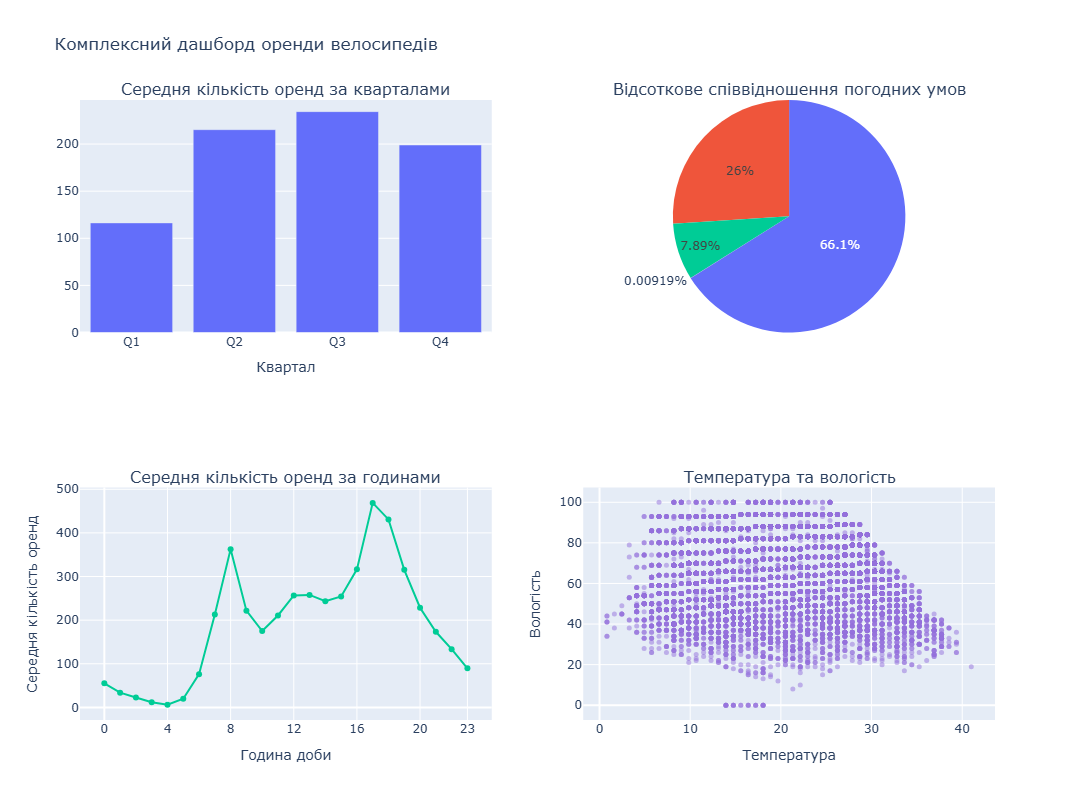

In [7]:
fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "xy"}, {"type": "domain"}],
        [{"type": "xy"}, {"type": "xy"}]
    ],
    subplot_titles=(
    'Середня кількість оренд за кварталами',
    'Відсоткове співвідношення погодних умов',
    'Середня кількість оренд за годинами',
    'Температура та вологість'
    )
)

# Графік 1: Bar chart
season_avg = (df.groupby('quarter_name', as_index=False)['count'].mean())
fig.add_trace(
    go.Bar(
        x=season_avg['quarter_name'],
        y=season_avg['count'],
        name='Середня кількість оренд',
        hovertemplate='<b>Квартал:</b> %{x}<br><b>Середня кількість оренд:</b> %{y:.1f}<extra></extra>'
    ),
    row=1, col=1
)

# Графік 2: Pie chart
weather_agr = df['weather'].value_counts().sort_index()
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}
fig.add_trace(
    go.Pie(
        labels=weather_agr.index.map(weather_labels),
        values=weather_agr.values,
        name='Погодні умови',
        hovertemplate='<b>Погода:</b> %{label}<br><b>Кількість:</b> %{value}<br><b>Частка:</b> %{percent}<extra></extra>'
    ),
    row=1, col=2
)

# Графік 3: Line chart
hourly_rentals = (df.groupby('hour', as_index=False)['count'].mean().sort_values('hour'))

fig.add_trace(
    go.Scatter(
        x=hourly_rentals['hour'],
        y=hourly_rentals['count'],
        mode='lines+markers',
        name='Середня кількість оренд',
        hovertemplate='<b>Година:</b> %{x}<br><b>Середня кількість оренд:</b> %{y:.1f}<extra></extra>'
    ),
    row=2, col=1
)

# Графік 4: Scatter з кольором
fig.add_trace(
    go.Scatter(
        x=df['temp'],
        y=df['humidity'],
        mode='markers',
        name='Температура vs вологість',
        hovertemplate='<b>Температура:</b> %{x}<br><b>Вологість:</b> %{y}<extra></extra>',
        marker=dict(
            size=5,
            color='mediumpurple',
            opacity=0.5
        )
    ),
    row=2, col=2
)


fig.update_layout(
    height=800,
    showlegend=False,
    title_text="Комплексний дашборд оренди велосипедів"
)
fig.update_xaxes(title_text='Квартал', row=1, col=1)
fig.update_xaxes(title_text='Година доби',
    tickmode='array',
    tickvals=[0, 4, 8, 12, 16, 20, 23],
    row=2, col=1
)
fig.update_yaxes(title_text='Середня кількість оренд', row=2, col=1)
fig.update_xaxes(title_text='Температура', row=2, col=2)
fig.update_yaxes(title_text='Вологість', row=2, col=2)

fig.show()

Об’єднання кількох графіків в один дашборд дає змогу бачити дані комплексно та швидше знаходити взаємозв’язки між різними показниками. Це зручно для аналізу, оскільки в одному місці можна одночасно оцінити сезонність, погодні умови, погодинну динаміку оренд і зв’язок між температурою та вологістю. Такий підхід робить аналіз більш наочним і допомагає швидше робити висновки.

## Завдання 5 (Опціональне): 3D візуалізація

**Завдання:**
Створіть 3D scatter plot для аналізу взаємозв'язку температури, швидкості вітру та загальної кількості орендованих велосипедів. Колір встановіть за сезоном(кварталом), а розмір - за загальною кількість оренд також.

Дайте відповіді на питання.
**Питання для інтерпретації:**
1. Яку додаткову інформацію, на ваш погляд, дає 3D візуалізація?
2. Чи видно кластери в 3D просторі?
3. Чи ви можете зробити висновки з цієї візуалізації, чи вам було простіше побудувати кілька 2D?



In [8]:
fig = px.scatter_3d(
    df,
    x='temp',
    y='windspeed',
    z='count',
    color='quarter_name',
    size='count',
    title='3D-візуалізація оренди велосипедів'
)

fig.update_layout(
    height=700,
    scene=dict(
        xaxis_title='Температура',
        yaxis_title='Швидкість вітру',
        zaxis_title='Кількість оренд'
    )
)

fig.show()

1. **Яку додаткову інформацію дає 3D-візуалізація?**  
   3D-візуалізація дозволяє одночасно побачити взаємозв’язок між температурою, швидкістю вітру та кількістю оренд. Це дає більш об’ємне уявлення про дані, ніж звичайний 2D-графік, оскільки можна аналізувати одразу три змінні в одному просторі.

2. **Чи видно кластери в 3D-просторі?**  
   Так, у 3D-просторі можна помітити певне групування точок за кварталами та діапазонами значень. Проте через велику кількість точок окремі зони виглядають дуже щільними, тому межі між кластерами не завжди чіткі.

3. **Чи легко робити висновки з цієї візуалізації, чи простіше було б побудувати кілька 2D?**  
   3D-графік корисний для загального огляду та демонстрації взаємозв’язку між трьома змінними, але для точнішої інтерпретації часто зручніше використовувати кілька 2D-візуалізацій. Вони зазвичай читаються простіше та дозволяють швидше помітити закономірності.


## Завдання 6: Експорт та збереження інтерактивних графіків

**Завдання:**
Збережіть побудований попередній графік на plotly в формат HTML. Також змініть вручну щось на графіку (зум, виділення частини графіку) і збережіть його як статичне зображення через іконку фотоапарату у формат PNG. Завантажте файли з графіком у HTML та PNG (або посилання на них на github) разом з посиланням на цей ноутбук при здачі ДЗ.


In [9]:
# Зберегти як HTML
fig.write_html("3d_rentals_task5.html")

Графік збережено у форматі HTML за допомогою `write_html()`.  
Статичне зображення у форматі PNG збережено вручну через іконку камери після взаємодії з графіком.

**Time spent — 3 години**

**What I learned:**
- Навчилася будувати **інтерактивні графіки в Plotly**: `line`, `scatter`, `bar`, `pie`, `scatter_3d` і дашборд через `make_subplots`.
- Побачила різницю між **Plotly Express** і **Graph Objects**: перший — швидше, другий — гнучкіший у налаштуваннях.
- Практикувала **підготовку даних для графіків**: групування по місяцях, годинах і кварталах.
- Навчилася налаштовувати **hover, підписи осей, назви графіків** і читабельність візуалізацій.
- Спробувала **експорт графіків** у HTML і PNG.
- Краще розібралася з типовими помилками в **Plotly/Jupyter** та способами їх виправлення.